# Analyse bidimensionnelle ciblee 

Ce notebook propose une **analyse bidimensionnelle en Python** sur les donnees Parcoursup du projet.

On se concentre sur trois angles de lecture :
- la **dimension de genre** via la part de filles parmi les admis ;
- la **dimension territoriale** via la region de l'etablissement et le niveau d'ancrage local des admis ;
- la **dimension sociale** via la part d'admis boursiers.

Attention : la base ne contient pas des individus ligne par ligne, mais des **formations**. On interprete donc les resultats comme des **profils de formations** et non comme des comportements individuels.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)

In [18]:
DATA_PATH = Path("../data/raw/Parcoursup.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/Parcoursup.csv")

df_raw = pd.read_csv(DATA_PATH, sep=";")
print(f"Jeu brut : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")


def clean_cat(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "nd": pd.NA})
    )


def clean_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(clean_cat(series).str.replace(",", ".", regex=False), errors="coerce")


df = pd.DataFrame({
    "region": clean_cat(df_raw["Région de l’établissement"]),
    "academie": clean_cat(df_raw["Académie de l’établissement"]),
    "filiere": clean_cat(df_raw["Filière de formation très agrégée"]),
    "selectivite": clean_cat(df_raw["Sélectivité"]),
    "capacite": clean_num(df_raw["Capacité de l’établissement par formation"]),
    "candidats_total": clean_num(df_raw["Effectif total des candidats pour une formation"]),
    "admis_total": clean_num(df_raw["Effectif total des candidats ayant accepté la proposition de l’établissement (admis)"]),
    "pct_filles": clean_num(df_raw["% d’admis dont filles"]),
    "pct_boursiers": clean_num(df_raw["% d’admis néo bacheliers boursiers"]),
    "taux_acces": clean_num(df_raw["Taux d’accès"]),
    "pct_meme_academie": clean_num(df_raw["% d’admis néo bacheliers issus de la même académie"]),
})

df["pression"] = df["candidats_total"] / df["capacite"].replace(0, np.nan)

regions_top10 = df["region"].value_counts(dropna=True).head(10).index
df["region_groupee"] = df["region"].where(df["region"].isin(regions_top10), "Autres regions")
df["region_groupee"] = df["region_groupee"].fillna("Region non renseignee")

df["profil_genre"] = pd.cut(
    df["pct_filles"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["plus d'hommes", "Mixte", "plus de femmes"],
)
df["profil_genre"] = df["profil_genre"].astype("object").fillna("Non renseigne")

df["profil_boursier"] = pd.cut(
    df["pct_boursiers"],
    bins=[-np.inf, 15, 30, np.inf],
    labels=["Peu de boursiers", "équilibré", "bcp de boursiers"],
)
df["profil_boursier"] = df["profil_boursier"].astype("object").fillna("Non renseigne")

df["ancrage_local"] = pd.cut(
    df["pct_meme_academie"],
    bins=[-np.inf, 40, 70, np.inf],
    labels=["Faible ancrage local", "Ancrage intermediaire", "Fort ancrage local"],
)
df["ancrage_local"] = df["ancrage_local"].astype("object").fillna("Non renseigne")

analysis = df.loc[
    df[["region_groupee", "profil_genre", "profil_boursier", "pct_filles", "pct_boursiers", "taux_acces", "pression"]]
    .notna()
    .any(axis=1)
].copy()

for col in ["capacite", "candidats_total", "admis_total", "pct_filles", "pct_boursiers", "taux_acces", "pct_meme_academie", "pression"]:
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

print(f"Jeu d'analyse : {analysis.shape[0]} lignes")
analysis.head()

Jeu brut : 14252 lignes x 118 colonnes
Jeu d'analyse : 14252 lignes


,region,academie,filiere,selectivite,capacite,candidats_total,admis_total,pct_filles,pct_boursiers,taux_acces,pct_meme_academie,pression,region_groupee,profil_genre,profil_boursier,ancrage_local
0,Auvergne-Rhône-Alpes,Lyon,Autre formation,formation sélective,40,936,40,82.0,23.0,13,31.0,23.4,Auvergne-Rhône-Alpes,plus de femmes,équilibré,Faible ancrage local
1,Ile-de-France,Créteil,Licence,formation non sélective,32,249,30,77.0,17.0,98,33.0,7.78125,Ile-de-France,plus de femmes,équilibré,Faible ancrage local
2,Auvergne-Rhône-Alpes,Lyon,IFSI,formation sélective,56,2791,56,89.0,16.0,40,84.0,49.839286,Auvergne-Rhône-Alpes,plus de femmes,équilibré,Fort ancrage local
3,Auvergne-Rhône-Alpes,Lyon,PASS,formation non sélective,195,5973,194,54.0,13.0,36,71.0,30.630769,Auvergne-Rhône-Alpes,Mixte,Peu de boursiers,Fort ancrage local
4,Auvergne-Rhône-Alpes,Lyon,PASS,formation non sélective,75,5472,75,87.0,18.0,20,75.0,72.96,Auvergne-Rhône-Alpes,plus de femmes,équilibré,Fort ancrage local


## 1. Lecture rapide des variables retenues

Avant de comparer les variables deux a deux, on verifie que les indicateurs retenus sont bien exploitables.

Ici, la variable la plus delicate est l'idee de **region d'origine**. La base ne donne pas directement la region d'origine individuelle des candidats. On utilise donc deux lectures complementaires :
- la **region de l'etablissement**, qui decrit le contexte geographique de la formation ;
- la part d'admis issus de la **meme academie**, qui sert de **proxy d'ancrage local**.

In [11]:
missing = pd.DataFrame({
    "type": analysis.dtypes.astype(str),
    "nb_manquants": analysis.isna().sum(),
    "pct_manquants": (analysis.isna().mean() * 100).round(1),
    "nb_modalites_ou_valeurs": analysis.nunique(dropna=True),
}).sort_values(["pct_manquants", "nb_modalites_ou_valeurs"], ascending=[True, False])

display(missing)

display(
    analysis[["pct_filles", "pct_boursiers", "taux_acces", "pression", "pct_meme_academie"]]
    .describe()
    .round(2)
)

,type,nb_manquants,pct_manquants,nb_modalites_ou_valeurs
pression,Float64,4,0.0,8075
candidats_total,Int64,0,0.0,3244
admis_total,Int64,0,0.0,462
capacite,Int64,0,0.0,348
pct_filles,Float64,0,0.0,101
pct_meme_academie,Float64,0,0.0,101
pct_boursiers,Float64,0,0.0,92
academie,string,0,0.0,33
filiere,string,0,0.0,11
region_groupee,string,0,0.0,11


,pct_filles,pct_boursiers,taux_acces,pression,pct_meme_academie
count,14252.0,14252.0,13076.0,14248.0,14252.0
mean,50.0,22.27,58.3,21.1,69.53
std,29.62,17.77,29.37,33.52,28.77
min,0.0,0.0,1.0,0.05,0.0
25%,25.0,9.0,33.0,6.17,52.0
50%,53.0,20.0,58.0,11.42,78.0
75%,75.0,32.0,86.0,23.5,93.0
max,100.0,100.0,100.0,904.67,100.0


## 2. Comparaisons quali-quali

On commence par une lecture purement qualitative.

L'idee est de voir si certains types de formations cumulent :
- une composition plus feminine ou plus masculine ;
- une presence plus ou moins forte de boursiers ;
- un ancrage territorial plus ou moins local selon les regions.

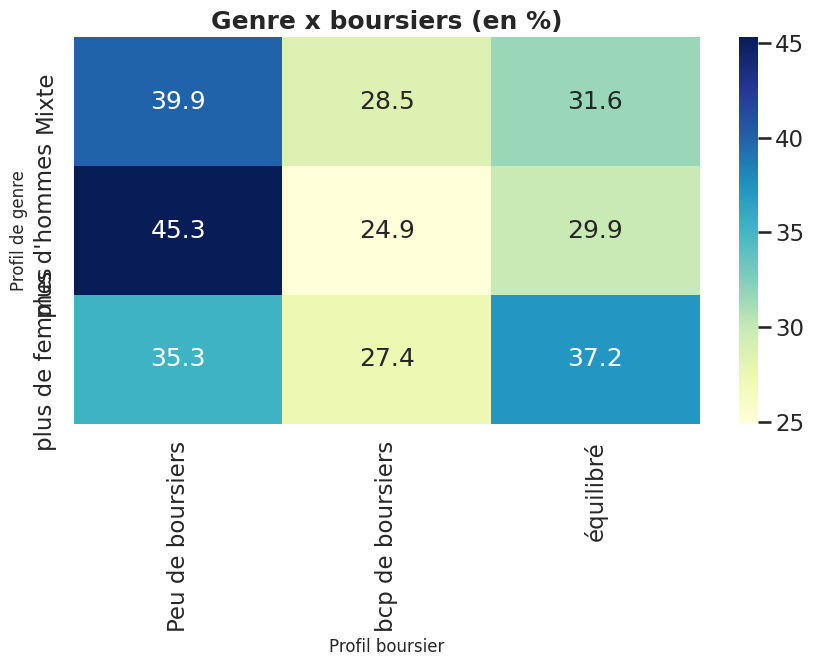

<Figure size 1000x800 with 0 Axes>

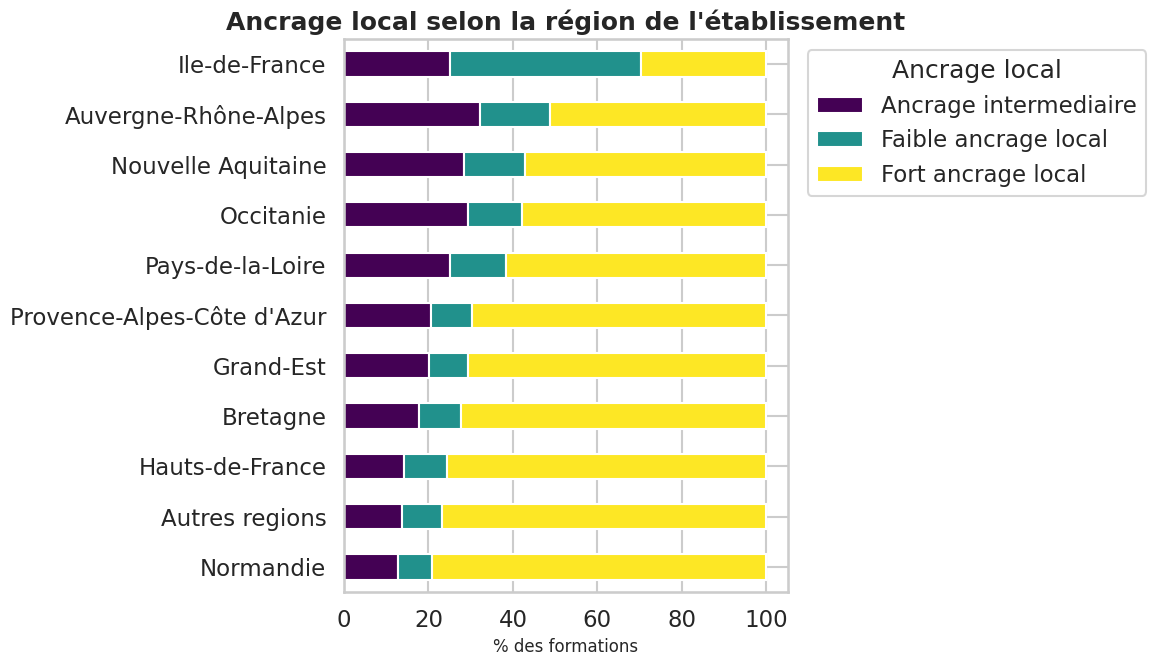

profil_boursier,Peu de boursiers,bcp de boursiers,équilibré
profil_genre,,,
Mixte,39.9,28.5,31.6
plus d'hommes,45.3,24.9,29.9
plus de femmes,35.3,27.4,37.2


ancrage_local,Ancrage intermediaire,Faible ancrage local,Fort ancrage local
region_groupee,,,
Normandie,12.8,8.1,79.1
Autres regions,13.7,9.5,76.8
Hauts-de-France,14.3,10.1,75.6
Bretagne,17.8,10.0,72.2
Grand-Est,20.3,9.1,70.6
Provence-Alpes-Côte d'Azur,20.6,9.8,69.7
Pays-de-la-Loire,25.1,13.2,61.7
Occitanie,29.3,12.8,57.9
Nouvelle Aquitaine,28.4,14.5,57.1


In [20]:
# Préparation des données
quali_df = analysis[["profil_genre", "profil_boursier", "ancrage_local", "region_groupee"]].dropna().copy()

genre_boursier = pd.crosstab(
    quali_df["profil_genre"],
    quali_df["profil_boursier"],
    normalize="index"
).mul(100)

region_ancrage = pd.crosstab(
    quali_df["region_groupee"],
    quali_df["ancrage_local"],
    normalize="index"
).mul(100)

# --- Plot 1 : Heatmap Genre x Boursier ---
plt.figure(figsize=(9, 7))
sns.heatmap(
    genre_boursier.round(1),
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Genre x boursiers (en %)")
plt.xlabel("Profil boursier")
plt.ylabel("Profil de genre")
plt.tight_layout()
plt.show()


# --- Plot 2 : Barres horizontales empilées ---
plt.figure(figsize=(10, 8))

region_ancrage_sorted = region_ancrage.sort_values("Fort ancrage local", ascending=False)

region_ancrage_sorted.plot(
    kind="barh",
    stacked=True,
    colormap="viridis"
)

plt.title("Ancrage local selon la région de l'établissement")
plt.xlabel("% des formations")
plt.ylabel("")
plt.legend(title="Ancrage local", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Affichage des tables
display(genre_boursier.round(1))
display(region_ancrage_sorted.round(1).head(12))

## 3. Comparaisons quanti-quanti

Cette fois, on observe les relations entre variables numeriques. Deux questions simples guident la lecture :
- la feminisation et la part de boursiers evoluent-elles ensemble ?
- ces profils sont-ils associes a l'accessibilite ou a la pression des formations ?

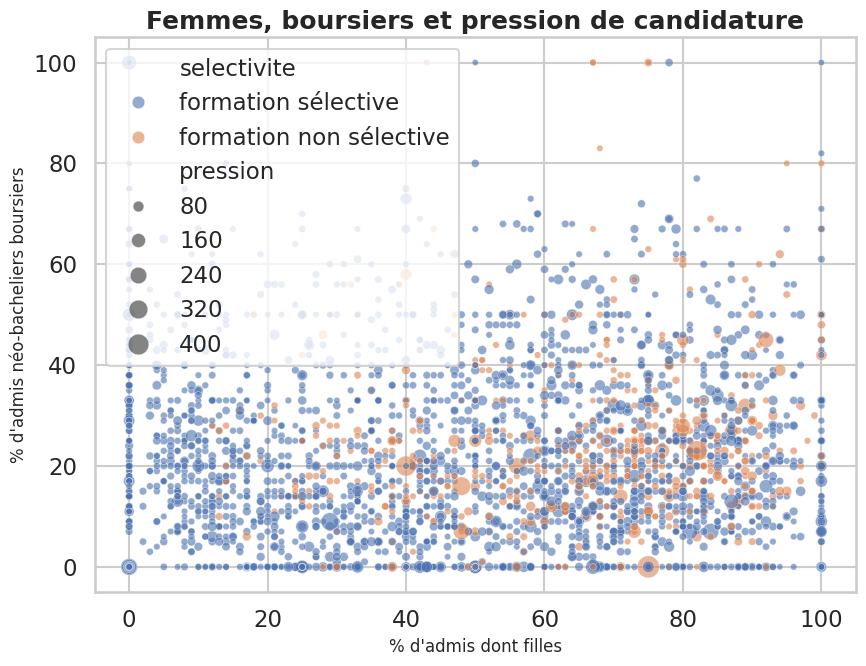

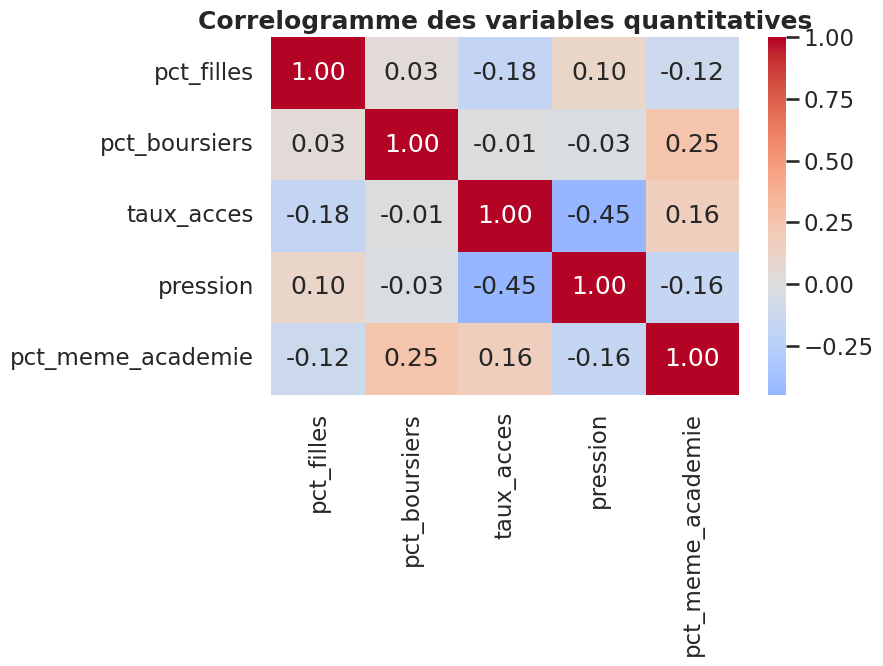

,pct_filles,pct_boursiers,taux_acces,pression,pct_meme_academie
pct_filles,1.000,0.034,-0.176,0.104,-0.121
pct_boursiers,0.034,1.000,-0.010,-0.028,0.251
taux_acces,-0.176,-0.010,1.000,-0.448,0.164
pression,0.104,-0.028,-0.448,1.000,-0.165
pct_meme_academie,-0.121,0.251,0.164,-0.165,1.000


In [23]:
quanti_cols = ["pct_filles", "pct_boursiers", "taux_acces", "pression", "pct_meme_academie"]

quanti = analysis[quanti_cols + ["selectivite"]].dropna(
    subset=["pct_filles", "pct_boursiers", "taux_acces", "pression"]
).copy()

for col in quanti_cols:
    quanti[col] = quanti[col].astype(float)

# --- Plot 1 : scatterplot ---
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=quanti.sample(min(3000, len(quanti)), random_state=42),
    x="pct_filles",
    y="pct_boursiers",
    hue="selectivite",
    size="pression",
    sizes=(20, 250),
    alpha=0.6,
)

plt.title("Femmes, boursiers et pression de candidature")
plt.xlabel("% d'admis dont filles")
plt.ylabel("% d'admis néo-bacheliers boursiers")
plt.tight_layout()
plt.show()


# --- Plot 2 : heatmap des corrélations ---
corr = quanti[quanti_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlogramme des variables quantitatives")
plt.tight_layout()
plt.show()

display(corr.round(3))

## 4. Comparaisons mixtes : quali-quanti

C'est souvent la partie la plus parlante dans une analyse bidimensionnelle appliquée.

On cherche ici a repondre a des questions du type :
- les formations majoritairement feminines sont-elles plus accessibles ?
- la pression de candidature differe-t-elle selon la place des boursiers ?
- certaines regions se distinguent-elles par des profils sociaux ou de genre ?

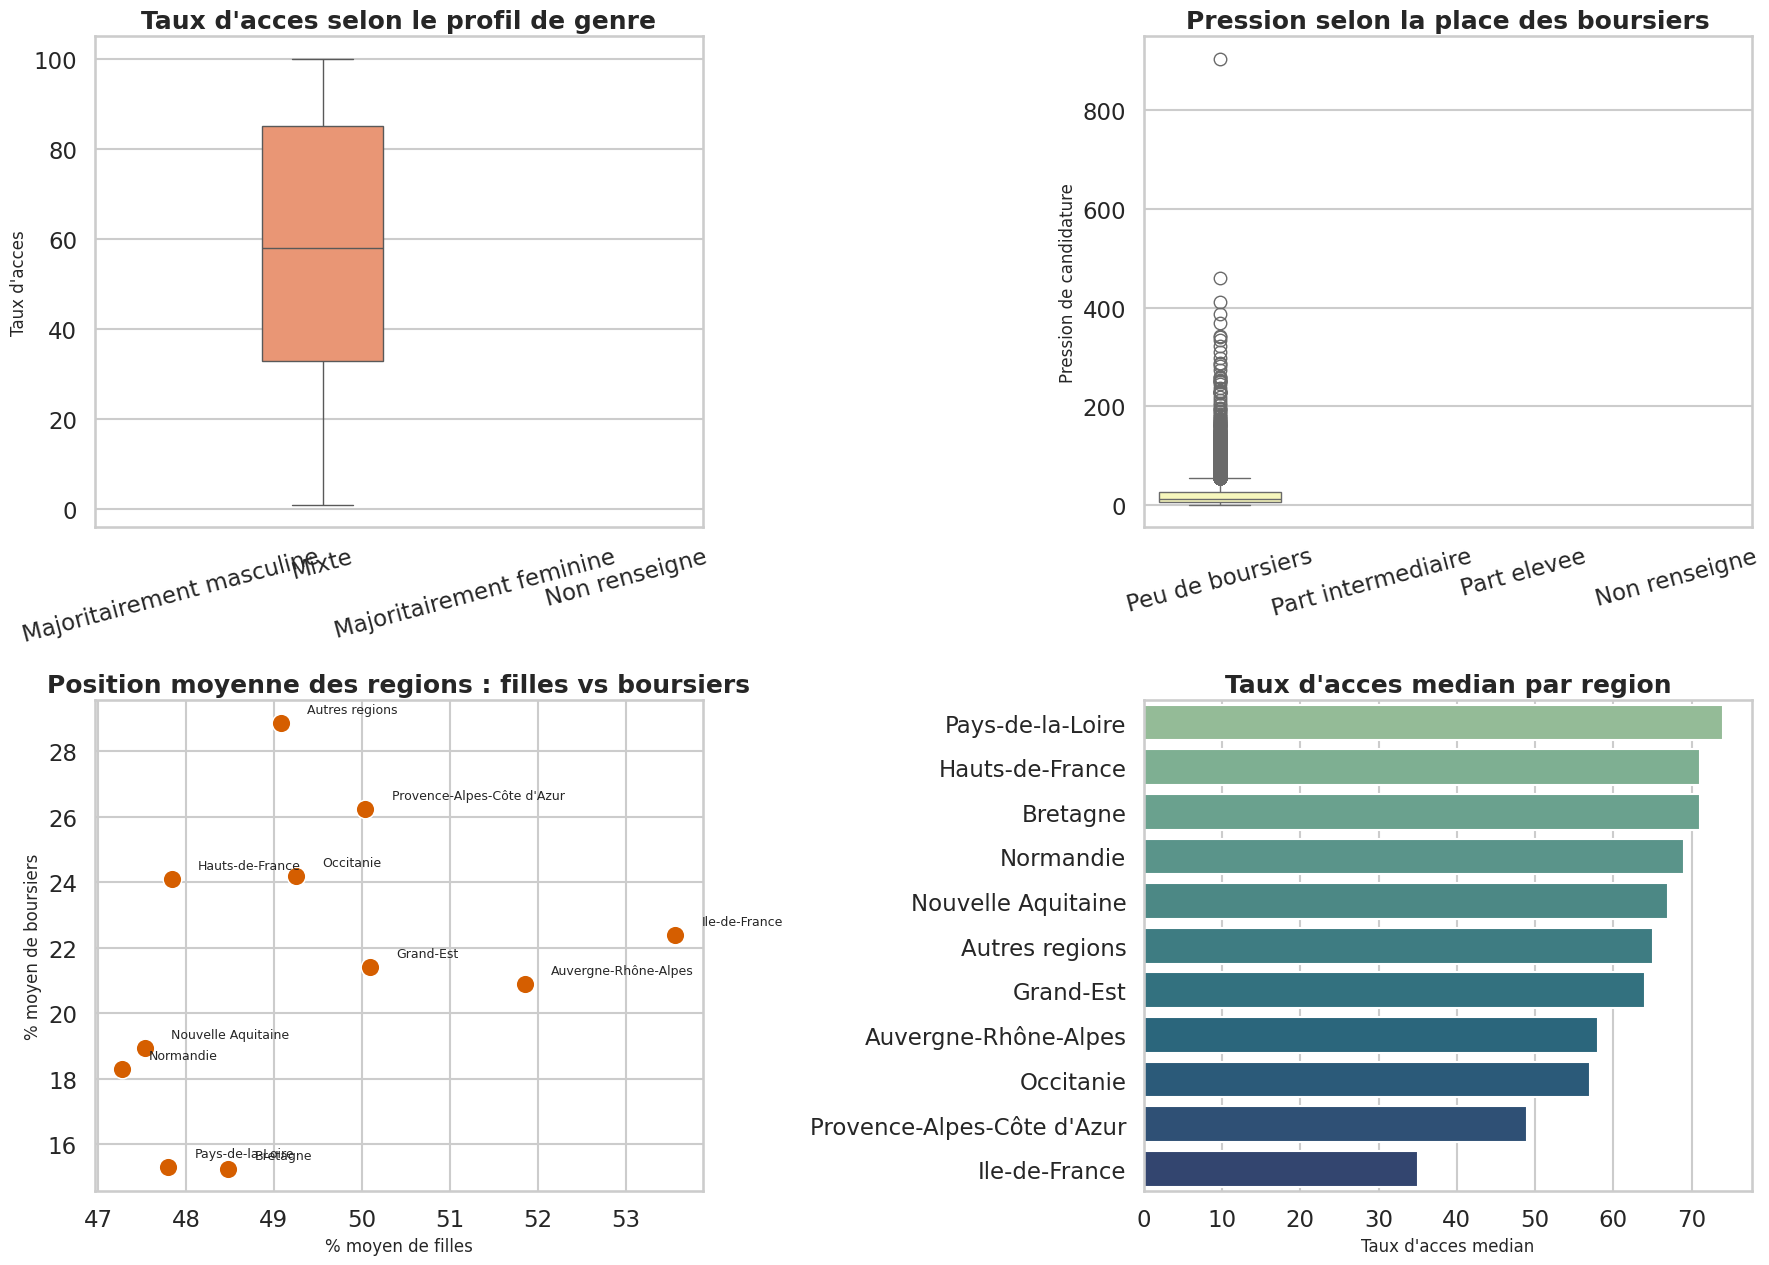

,pct_filles,pct_boursiers
region_groupee,,
Autres regions,49.08,28.87
Provence-Alpes-Côte d'Azur,50.04,26.23
Occitanie,49.25,24.18
Hauts-de-France,47.84,24.11
Ile-de-France,53.56,22.38
Grand-Est,50.09,21.41
Auvergne-Rhône-Alpes,51.85,20.89
Nouvelle Aquitaine,47.53,18.94
Normandie,47.28,18.29


In [24]:
mix_df = analysis.copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

order_genre = ["Majoritairement masculine", "Mixte", "Majoritairement feminine", "Non renseigne"]
order_boursier = ["Peu de boursiers", "Part intermediaire", "Part elevee", "Non renseigne"]

sns.boxplot(
    data=mix_df,
    x="profil_genre",
    y="taux_acces",
    order=order_genre,
    hue="profil_genre",
    palette="Set2",
    dodge=False,
    ax=axes[0, 0],
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_title("Taux d'acces selon le profil de genre")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Taux d'acces")
axes[0, 0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=mix_df,
    x="profil_boursier",
    y="pression",
    order=order_boursier,
    hue="profil_boursier",
    palette="Set3",
    dodge=False,
    ax=axes[0, 1],
)
if axes[0, 1].legend_ is not None:
    axes[0, 1].legend_.remove()
axes[0, 1].set_title("Pression selon la place des boursiers")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Pression de candidature")
axes[0, 1].tick_params(axis="x", rotation=15)

region_summary = (
    mix_df.groupby("region_groupee")[["pct_filles", "pct_boursiers"]]
    .mean()
    .sort_values("pct_boursiers", ascending=False)
)

sns.scatterplot(
    data=region_summary.reset_index(),
    x="pct_filles",
    y="pct_boursiers",
    s=180,
    color="#d55e00",
    ax=axes[1, 0],
)
for _, row in region_summary.reset_index().iterrows():
    axes[1, 0].text(row["pct_filles"] + 0.3, row["pct_boursiers"] + 0.3, row["region_groupee"], fontsize=9)
axes[1, 0].set_title("Position moyenne des regions : filles vs boursiers")
axes[1, 0].set_xlabel("% moyen de filles")
axes[1, 0].set_ylabel("% moyen de boursiers")

acces_region = (
    mix_df.groupby("region_groupee")[["taux_acces"]]
    .median()
    .sort_values("taux_acces", ascending=False)
    .head(12)
)
sns.barplot(
    data=acces_region.reset_index(),
    x="taux_acces",
    y="region_groupee",
    hue="region_groupee",
    palette="crest",
    dodge=False,
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Taux d'acces median par region")
axes[1, 1].set_xlabel("Taux d'acces median")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

display(region_summary.round(2))

## 5. Tableau de synthese interpretable

On termine par un tableau compact qui aide a commenter les profils les plus nets.

Il ne remplace pas les graphiques, mais il permet de repérer rapidement les categories qui se distinguent le plus.

In [7]:
synthese = (
    mix_df.groupby(["profil_genre", "profil_boursier"])
    .agg(
        nb_formations=("filiere", "size"),
        taux_acces_median=("taux_acces", "median"),
        pression_mediane=("pression", "median"),
        part_locale_mediane=("pct_meme_academie", "median"),
    )
    .sort_values(["nb_formations", "taux_acces_median"], ascending=[False, False])
)

display(synthese.round(2).head(15))

nb_formations  \
profil_genre              profil_boursier                     
Majoritairement masculine Peu de boursiers             2431   
Majoritairement feminine  Part intermediaire           2242   
                          Peu de boursiers             2129   
                          Part elevee                  1652   
Majoritairement masculine Part intermediaire           1604   
                          Part elevee                  1336   
Mixte                     Peu de boursiers             1140   
                          Part intermediaire            903   
                          Part elevee                   815   

                                              taux_acces_median  \
profil_genre              profil_boursier                         
Majoritairement masculine Peu de boursiers                 69.0   
Majoritairement feminine  Part intermediaire               49.0   
                          Peu de boursiers                 47.0   
                          Part elevee                      50.0   
Majoritairement masculine Part intermediaire               67.0   
                          Part elevee                      62.5   
Mixte                     Peu de boursiers                 59.5   
                          Part intermediaire               60.0   
                          Part elevee                      55.0   

                                              pression_mediane  \
profil_genre              profil_boursier                        
Majoritairement masculine Peu de boursiers               10.67   
Majoritairement feminine  Part intermediaire             13.39   
                          Peu de boursiers               12.92   
                          Part elevee                    12.53   
Majoritairement masculine Part intermediaire              9.78   
                          Part elevee                     9.06   
Mixte                     Peu de boursiers               12.47   
                          Part intermediaire             11.83   
                          Part elevee                     12.5   

                                              part_locale_mediane  
profil_genre              profil_boursier                          
Majoritairement masculine Peu de boursiers                   71.0  
Majoritairement feminine  Part intermediaire                 76.0  
                          Peu de boursiers                   62.0  
                          Part elevee                        83.0  
Majoritairement masculine Part intermediaire                 83.0  
                          Part elevee                        90.0  
Mixte                     Peu de boursiers                   69.0  
                          Part intermediaire                 80.0  
                          Part elevee                        89.0

## 6. Pistes d'interpretation

Quelques reperes pour commenter les sorties une fois le notebook execute :

- si une case ressort fortement dans la heatmap `profil_genre x profil_boursier`, cela suggere une **association structurelle** entre composition de genre et place des boursiers ;
- si le nuage `pct_filles x pct_boursiers` est tres disperse, cela indique au contraire une relation **faible ou tres heterogene** ;
- si certaines regions se regroupent en haut a droite du graphique regional, elles cumulent en moyenne **plus de filles et plus de boursiers** ;
- si les boxplots montrent des ecarts nets de mediane, on tient un argument simple pour une interpretation metier ;
- il faut toujours garder a l'esprit qu'on compare ici des **formations**, pas des individus isoles.

Pour prolonger cette analyse, on pourrait ensuite enchainer avec :
- une **ACM** sur les variables qualitatives derivees ;
- une **AFDM / FAMD** pour mixer directement les variables qualitatives et quantitatives ;
- une petite **classification** sur les profils factoriels obtenus.